# IMPORT LIBRARIES

Imports the necessary libraries for data manipulation, machine learning model building, and visualization, including `pandas`, `numpy`, `sklearn` modules for models and metrics, `seaborn` and `matplotlib.pyplot` for plotting, `imblearn` for handling imbalanced datasets, and `torch` for building and training deep learning models.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset

# LOAD DATASET

Loads the dataset named `COMBINED.csv` into a pandas DataFrame. Defines a list of `feature_columns` and extracts these features into a NumPy array `X_raw` and the target variable 'scratch_x' into a NumPy array `y`.

In [2]:
# Load the dataset
df = pd.read_csv('COMBINED.csv')

feature_columns = [
    'accelerometer_x', 'accelerometer_y', 'accelerometer_z',
    'gyroscope_x', 'gyroscope_y', 'gyroscope_z',
    'totalAcceleration_x', 'totalAcceleration_y', 'totalAcceleration_z',
    'magnetometer_x', 'magnetometer_y', 'magnetometer_z'
]
X_raw = df[feature_columns].values
y = df['scratch_x'].values


# TARGET VARIABLE DISTRIBUTION

Visualizes the distribution of the target variable 'scratch_x' (scratching vs. non-scratching) in the original dataset using a countplot from the `seaborn` library. Includes commented-out code for visualizing the distribution after applying SMOTE for oversampling.

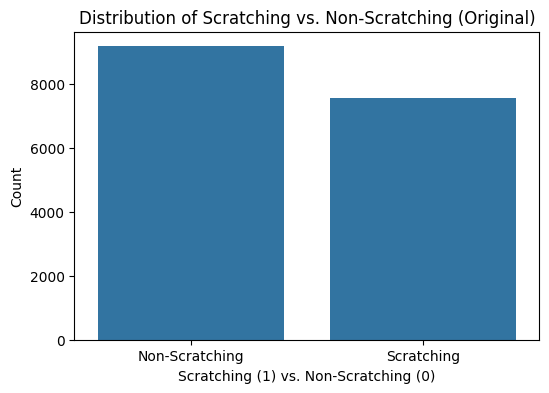

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='scratch_x', data=df)
plt.title('Distribution of Scratching vs. Non-Scratching (Original)')
plt.xlabel('Scratching (1) vs. Non-Scratching (0)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Scratching', 'Scratching'])
plt.show()

# CORRELATION PLOT AND DATA SPLITTING

Generates a correlation matrix heatmap to visualize the relationships between features and the target. Splits the raw data (`X_raw`, `y`) into training and testing sets using `train_test_split` (80% train, 20% test). Includes commented-out code for data normalization.

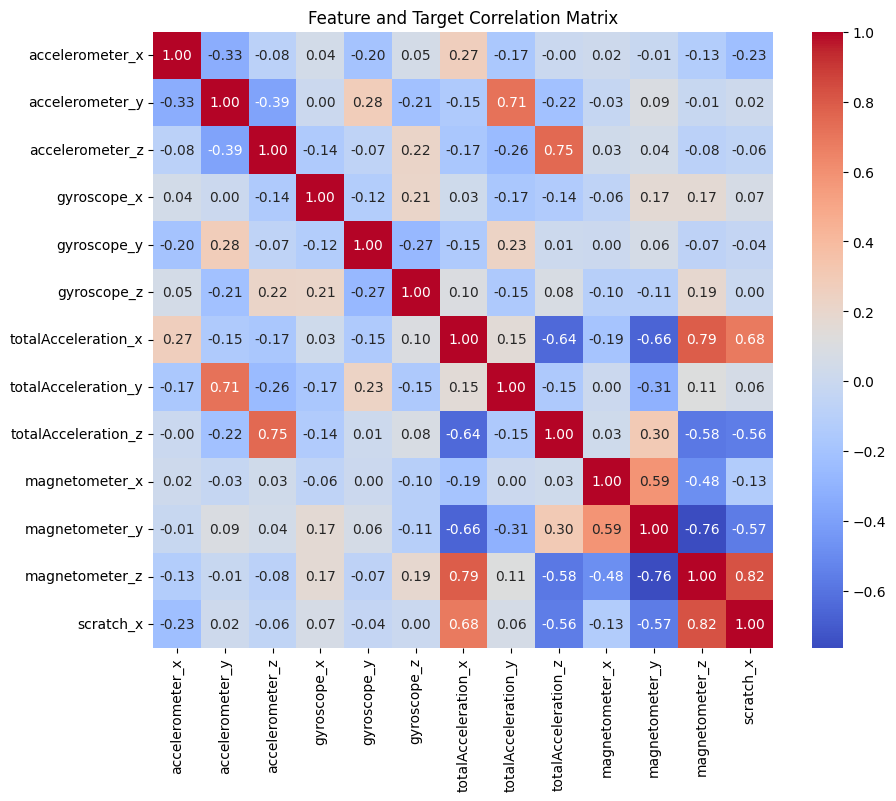

In [4]:
# Correlation Plot
correlation_matrix = df[feature_columns + ['scratch_x']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature and Target Correlation Matrix')
plt.show()


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

# RANDOM FOREST MODEL

Trains a Random Forest Classifier on the training data. Makes predictions on the test data and prints a classification report (precision, recall, F1-score). Generates and displays a confusion matrix heatmap to visualize performance.

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1825
           1       0.99      0.98      0.98      1524

    accuracy                           0.98      3349
   macro avg       0.98      0.98      0.98      3349
weighted avg       0.98      0.98      0.98      3349



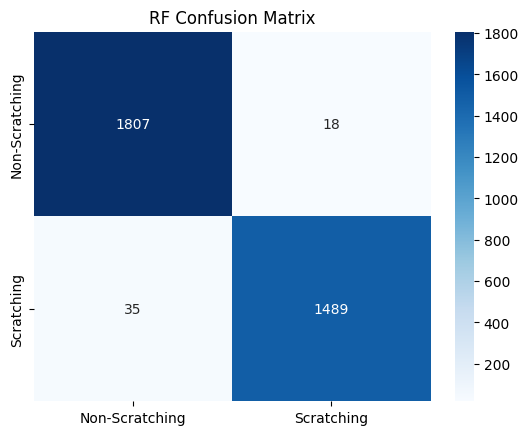

In [5]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Scratching', 'Scratching'], yticklabels=['Non-Scratching', 'Scratching'])
plt.title('RF Confusion Matrix')
plt.show()



# SVM MODEL

Trains a Support Vector Machine (SVM) classifier on the training data. Makes predictions on the test data and prints a classification report. Generates and displays a confusion matrix heatmap.

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1825
           1       1.00      0.93      0.96      1524

    accuracy                           0.97      3349
   macro avg       0.97      0.96      0.96      3349
weighted avg       0.97      0.97      0.96      3349



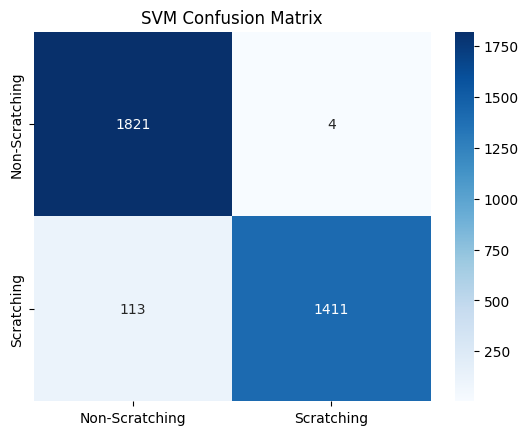

In [6]:
# SVM
svm = SVC(random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Scratching', 'Scratching'], yticklabels=['Non-Scratching', 'Scratching'])
plt.title('SVM Confusion Matrix')
plt.show()

# FEATURE IMPORTANCE

Calculates and visualizes the feature importances from the trained Random Forest model. Creates a pandas Series to associate importance scores with feature names, sorts them, and generates a bar plot to show the relative importance of each feature.

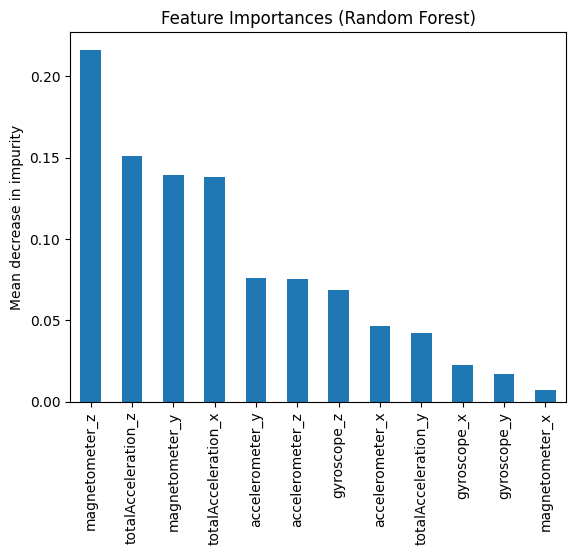

In [7]:
# Feature Importance.
importances = rf.feature_importances_
feature_names = feature_columns
feature_importance = pd.Series(importances, index=feature_names)

feature_importance = feature_importance.sort_values(ascending=False)

fig, ax = plt.subplots()
feature_importance.plot.bar(ax=ax)
ax.set_title("Feature Importances (Random Forest)")
ax.set_ylabel("Mean decrease in impurity")
plt.show()

# APPLY WINDOWING (TRAINING DATA)

Applies a sliding window approach to the raw training data (`X_raw`, `y`) with a `window_size` of 40 and `step_size` of 20. Creates overlapping windows of feature data (`X_windows`) and determines the majority class label for each window (`y_windows`) for training the Transformer models.

In [8]:
# Apply windowing
window_size = 40
step_size = 20
windows = []
labels = []
for i in range(0, len(df) - window_size, step_size):
    windows.append(X_raw[i:i + window_size])
    labels.append(np.bincount(y[i:i + window_size].astype(int)).argmax())
X_windows = np.array(windows)
y_windows = np.array(labels)

# TRANSFORMER MODEL DEFINITIONS AND TRAINING FUNCTION

Defines the architecture for `StandardTransformer` and `Conformer` models using PyTorch. Includes a `train_transformer` function that handles the training and evaluation loop, sets up data loaders, defines loss and optimizer, implements early stopping based on validation F1 score, saves the best model, and prints classification reports and confusion matrices.

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Training Conformer:
Epoch 1/20, Val F1: 0.5721
Epoch 2/20, Val F1: 0.7124
Epoch 3/20, Val F1: 0.9821
Epoch 4/20, Val F1: 0.9821
Epoch 5/20, Val F1: 0.9584
Epoch 6/20, Val F1: 0.9702
Epoch 7/20, Val F1: 0.9465
Early stopping triggered
Conformer Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        95
           1       1.00      0.96      0.98        73

    accuracy                           0.98       168
   macro avg       0.98      0.98      0.98       168
weighted avg       0.98      0.98      0.98       168



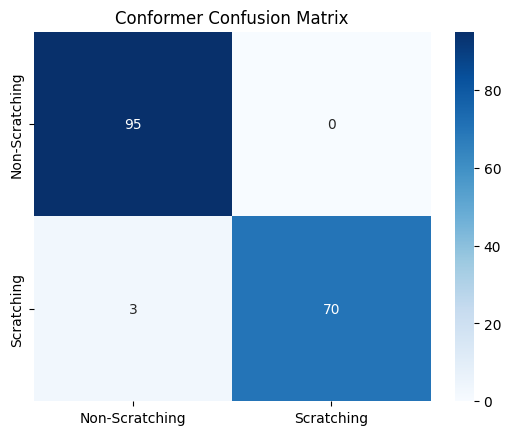

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(



Training Standard Transformer:
Epoch 1/20, Val F1: 0.2632
Epoch 2/20, Val F1: 0.2632
Epoch 3/20, Val F1: 0.2632
Epoch 4/20, Val F1: 0.6689
Epoch 5/20, Val F1: 0.9761
Epoch 6/20, Val F1: 0.9761
Epoch 7/20, Val F1: 0.9761
Epoch 8/20, Val F1: 0.9642
Epoch 9/20, Val F1: 0.9583
Early stopping triggered
Standard Transformer Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        95
           1       1.00      0.95      0.97        73

    accuracy                           0.98       168
   macro avg       0.98      0.97      0.98       168
weighted avg       0.98      0.98      0.98       168



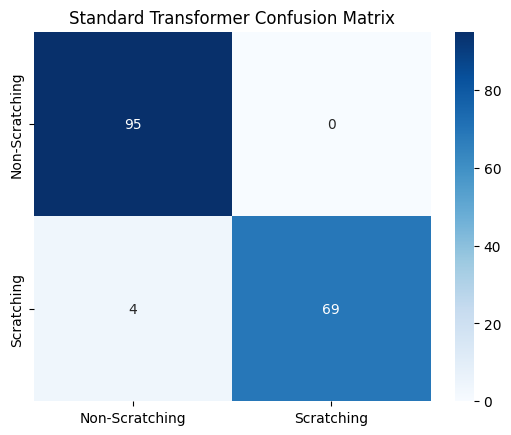

In [9]:
# Transformer Model Definitions
class StandardTransformer(nn.Module):
    def __init__(self, input_dim, num_classes, num_heads=4, num_layers=2, dim_feedforward=512, dropout=0.3):
        super(StandardTransformer, self).__init__()
        self.transformer_encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_dim, nhead=num_heads, dim_feedforward=dim_feedforward, dropout=dropout
        )
        self.transformer_encoder = nn.TransformerEncoder(self.transformer_encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(input_dim, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x.permute(1, 0, 2)  # (window_size, batch, input_dim)
        x = self.transformer_encoder(x)
        x = x[-1]
        x = self.dropout(x)
        x = self.fc(x)
        return x


class Conformer(nn.Module):
    def __init__(self, input_dim, num_classes, num_heads=4, num_layers=2, dim_feedforward=512, dropout=0.3):
        super(Conformer, self).__init__()
        self.conv = nn.Conv1d(input_dim, input_dim, kernel_size=3, padding=1)
        self.transformer_encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_dim, nhead=num_heads, dim_feedforward=dim_feedforward, dropout=dropout
        )
        self.transformer_encoder = nn.TransformerEncoder(self.transformer_encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(input_dim, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (batch, input_dim, window_size)
        x = self.conv(x)
        x = x.permute(2, 0, 1)  # (window_size, batch, input_dim)
        x = self.transformer_encoder(x)
        x = x[-1]
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Train and evaluate Transformer function
def train_transformer(model, X_train_t, y_train_t, X_test_t, y_test_t, model_name, num_epochs=20):
    train_dataset = TensorDataset(torch.tensor(X_train_t, dtype=torch.float32), torch.tensor(y_train_t, dtype=torch.long))
    test_dataset = TensorDataset(torch.tensor(X_test_t, dtype=torch.float32), torch.tensor(y_test_t, dtype=torch.long))
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    class_weights = torch.tensor([1.0, 10.0], dtype=torch.float32)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    best_val_f1 = 0
    patience = 5
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        model.eval()
        val_preds = []
        val_true = []
        with torch.no_grad():
            for inputs, targets in test_loader:
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                val_preds.extend(predicted.cpu().numpy())
                val_true.extend(targets.cpu().numpy())
        val_f1 = f1_score(val_true, val_preds, average='weighted')
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), f'best_{model_name.lower().replace(" ", "_")}_transformer.pt')
        else:
            patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break
        print(f"Epoch {epoch+1}/{num_epochs}, Val F1: {val_f1:.4f}")

    model.load_state_dict(torch.load(f'best_{model_name.lower().replace(" ", "_")}_transformer.pt'))
    model.eval()
    val_preds = []
    val_true = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            val_preds.extend(predicted.cpu().numpy())
            val_true.extend(targets.cpu().numpy())

    print(f"{model_name} Classification Report:")
    print(classification_report(val_true, val_preds))
    cm_transformer = confusion_matrix(val_true, val_preds)
    sns.heatmap(cm_transformer, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Scratching', 'Scratching'], yticklabels=['Non-Scratching', 'Scratching'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()
    return val_f1


# Prepare Transformer data
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_windows, y_windows, test_size=0.2, random_state=42)

# Choose and Train Transformer models
input_dim = X_windows.shape[2]
num_classes = 2

# Train Conformer
conformer_model = Conformer(input_dim, num_classes)
print("Training Conformer:")
conformer_f1 = train_transformer(conformer_model, X_train_t, y_train_t, X_test_t, y_test_t, model_name="Conformer", num_epochs=20)

# Train Standard Transformer
standard_transformer_model = StandardTransformer(input_dim, num_classes)
print("\nTraining Standard Transformer:")
standard_transformer_f1 = train_transformer(standard_transformer_model, X_train_t, y_train_t, X_test_t, y_test_t, model_name="Standard Transformer", num_epochs=20)



# LOAD VALIDATION DATASET

Loads the validation dataset named `VALID.csv` into a pandas DataFrame. Extracts the raw feature data (`X_raw_val`) and target variable (`y_val`) from this dataset for evaluating the trained models on unseen data.

In [10]:
# Load validation dataset
df_val = pd.read_csv('VALID.csv')
df_flat = pd.read_csv('FLAT.csv')
df_none = pd.read_csv('NONE.csv')
df_touch = pd.read_csv('TOUCH.csv')
df_slow = pd.read_csv('SLOW.csv')


feature_columns = [
    'accelerometer_x', 'accelerometer_y', 'accelerometer_z',
    'gyroscope_x', 'gyroscope_y', 'gyroscope_z',
    'totalAcceleration_x', 'totalAcceleration_y', 'totalAcceleration_z',
    'magnetometer_x', 'magnetometer_y', 'magnetometer_z'
]
# Extract features and target from validation data
X_raw_val = df_val[feature_columns].values
y_val = df_val['scratch_x'].values

X_raw_flat = df_flat[feature_columns].values
y_flat = df_flat['scratch_x'].values

X_raw_none = df_none[feature_columns].values
y_none = df_none['scratch_x'].values

X_raw_touch = df_touch[feature_columns].values
y_touch = df_touch['scratch_x'].values

X_raw_slow = df_slow[feature_columns].values
y_slow = df_slow['scratch_x'].values

# APPLY WINDOWING TO VALIDATION DATA

Defines and applies a function `apply_windowing` to the raw validation data (`X_raw_val`, `y_val`) using the same `window_size` and `step_size`. Creates windowed validation data (`X_windows_val`) and labels (`y_windows_val`), including handling for potential missing (NaN) values in labels within windows.

In [11]:
def apply_windowing(X, y, window_size, step_size):
    windows = []
    labels = []
    for i in range(0, len(X) - window_size, step_size):
        windows.append(X[i:i + window_size])
        window_labels = pd.Series(y[i:i + window_size]).fillna(-1).astype(int)
        valid_labels = window_labels[window_labels != -1]
        if valid_labels.size > 0:
            labels.append(np.bincount(valid_labels).argmax())
        else:
            labels.append(0)
    return np.array(windows), np.array(labels)

window_size = 40
step_size = 20

# Apply windowing to all datasets
X_windows_val, y_windows_val = apply_windowing(X_raw_val, y_val, window_size, step_size)
X_windows_flat, y_windows_flat = apply_windowing(X_raw_flat, y_flat, window_size, step_size)
X_windows_none, y_windows_none = apply_windowing(X_raw_none, y_none, window_size, step_size)
X_windows_touch, y_windows_touch = apply_windowing(X_raw_touch, y_touch, window_size, step_size)
X_windows_slow, y_windows_slow = apply_windowing(X_raw_slow, y_slow, window_size, step_size)

# LOAD BEST TRAINED MODELS

Loads the saved state dictionaries of the best-performing Conformer and Standard Transformer models. Initializes new model instances and loads the saved weights using `torch.load()`. Sets the models to evaluation mode (`model.eval()`) for making predictions.

In [12]:
# Load the best trained models
input_dim = X_windows.shape[2]
num_classes = 2

conformer_model = Conformer(input_dim, num_classes)
conformer_model.load_state_dict(torch.load('best_conformer_transformer.pt'))
conformer_model.eval()

standard_transformer_model = StandardTransformer(input_dim, num_classes)
standard_transformer_model.load_state_dict(torch.load('best_standard_transformer_transformer.pt'))
standard_transformer_model.eval()

print("Trained models loaded successfully.")

Trained models loaded successfully.


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


# MAKE PREDICTIONS ON VALIDATION DATA

Prepares the windowed validation data for inference using PyTorch `TensorDataset` and `DataLoader`. Uses the loaded Conformer and Standard Transformer models to make predictions on this data, storing the results as lists of numpy arrays.

In [13]:
# Ensure X_windows_val, X_windows_phone, etc are defined by applying windowing
window_size = 40
step_size = 20

# Define a helper function to make predictions on a given dataset
def predict_on_dataset(model, X_windows):
    dataset_inference = TensorDataset(torch.tensor(X_windows, dtype=torch.float32))
    loader_inference = DataLoader(dataset_inference, batch_size=32, shuffle=False)
    predictions = []
    with torch.no_grad():
        for inputs in loader_inference:
            inputs = inputs[0]
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            predictions.extend(predicted.cpu().numpy())
    return predictions

# Make predictions using the trained models on all datasets
conformer_predictions_val = predict_on_dataset(conformer_model, X_windows_val)
standard_transformer_predictions_val = predict_on_dataset(standard_transformer_model, X_windows_val)

conformer_predictions_flat = predict_on_dataset(conformer_model, X_windows_flat)
standard_transformer_predictions_flat = predict_on_dataset(standard_transformer_model, X_windows_flat)

conformer_predictions_none = predict_on_dataset(conformer_model, X_windows_none)
standard_transformer_predictions_none = predict_on_dataset(standard_transformer_model, X_windows_none)

conformer_predictions_touch = predict_on_dataset(conformer_model, X_windows_touch)
standard_transformer_predictions_touch = predict_on_dataset(standard_transformer_model, X_windows_touch)

conformer_predictions_slow = predict_on_dataset(conformer_model, X_windows_slow)
standard_transformer_predictions_slow = predict_on_dataset(standard_transformer_model, X_windows_slow)

# DISPLAY SAMPLE PREDICTIONS AND COUNTS

Displays a sample of the predictions made by the Conformer and Standard Transformer models on the validation dataset. Provides a count of the predicted classes (0 or 1) for each model to show the distribution of predictions.

In [14]:
datasets = {
    "VALID": (conformer_predictions_val, standard_transformer_predictions_val),
    "FLAT": (conformer_predictions_flat, standard_transformer_predictions_flat),
    "NONE": (conformer_predictions_none, standard_transformer_predictions_none),
    "TOUCH": (conformer_predictions_touch, standard_transformer_predictions_touch),
    "SLOW": (conformer_predictions_slow, standard_transformer_predictions_slow)
}

for dataset_name, (conformer_preds, standard_transformer_preds) in datasets.items():
    print(f"\n{dataset_name} Dataset Prediction Counts:")
    print("Conformer:")
    print(pd.Series(conformer_preds).value_counts())
    print("\nStandard Transformer:")
    print(pd.Series(standard_transformer_preds).value_counts())


VALID Dataset Prediction Counts:
Conformer:
0    207
1    147
Name: count, dtype: int64

Standard Transformer:
0    209
1    145
Name: count, dtype: int64

FLAT Dataset Prediction Counts:
Conformer:
0    325
Name: count, dtype: int64

Standard Transformer:
0    325
Name: count, dtype: int64

NONE Dataset Prediction Counts:
Conformer:
0    245
Name: count, dtype: int64

Standard Transformer:
0    245
Name: count, dtype: int64

TOUCH Dataset Prediction Counts:
Conformer:
0    105
1     29
Name: count, dtype: int64

Standard Transformer:
0    107
1     27
Name: count, dtype: int64

SLOW Dataset Prediction Counts:
Conformer:
0    105
1     48
Name: count, dtype: int64

Standard Transformer:
0    105
1     48
Name: count, dtype: int64


# COUNT SCRATCHING ACTIONS

Defines and uses a function `count_scratching_actions` to count the number of distinct scratching events predicted by each model based on consecutive '1' predictions in the windowed data. Prints the total number of predicted scratching actions for both models on the validation dataset.

In [15]:
def count_scratching_actions(predictions):
    """Counts consecutive blocks of '1's as scratching actions."""
    scratch_actions = 0
    in_scratch = False
    for pred in predictions:
        if pred == 1 and not in_scratch:
            scratch_actions += 1
            in_scratch = True
        elif pred == 0:
            in_scratch = False
    return scratch_actions

for dataset_name, (conformer_preds, standard_transformer_preds) in datasets.items():
    conformer_scratch_actions = count_scratching_actions(conformer_preds)
    standard_transformer_scratch_actions = count_scratching_actions(standard_transformer_preds)
    print(f"\nNumber of predicted scratching actions by Conformer on {dataset_name}.csv: {conformer_scratch_actions}")
    print(f"Number of predicted scratching actions by Standard Transformer on {dataset_name}.csv: {standard_transformer_scratch_actions}")


Number of predicted scratching actions by Conformer on VALID.csv: 20
Number of predicted scratching actions by Standard Transformer on VALID.csv: 20

Number of predicted scratching actions by Conformer on FLAT.csv: 0
Number of predicted scratching actions by Standard Transformer on FLAT.csv: 0

Number of predicted scratching actions by Conformer on NONE.csv: 0
Number of predicted scratching actions by Standard Transformer on NONE.csv: 0

Number of predicted scratching actions by Conformer on TOUCH.csv: 6
Number of predicted scratching actions by Standard Transformer on TOUCH.csv: 5

Number of predicted scratching actions by Conformer on SLOW.csv: 4
Number of predicted scratching actions by Standard Transformer on SLOW.csv: 4


# PREDICTED SCRATCHING ACTIONS OVER TIME

Generates a time series plot visualizing the predicted scratching actions (1) and non-scratching actions (0) over time for both the Conformer and Standard Transformer models on the `VALID.csv` dataset. The x-axis represents time based on the step size and window index, and the y-axis shows the predicted label.

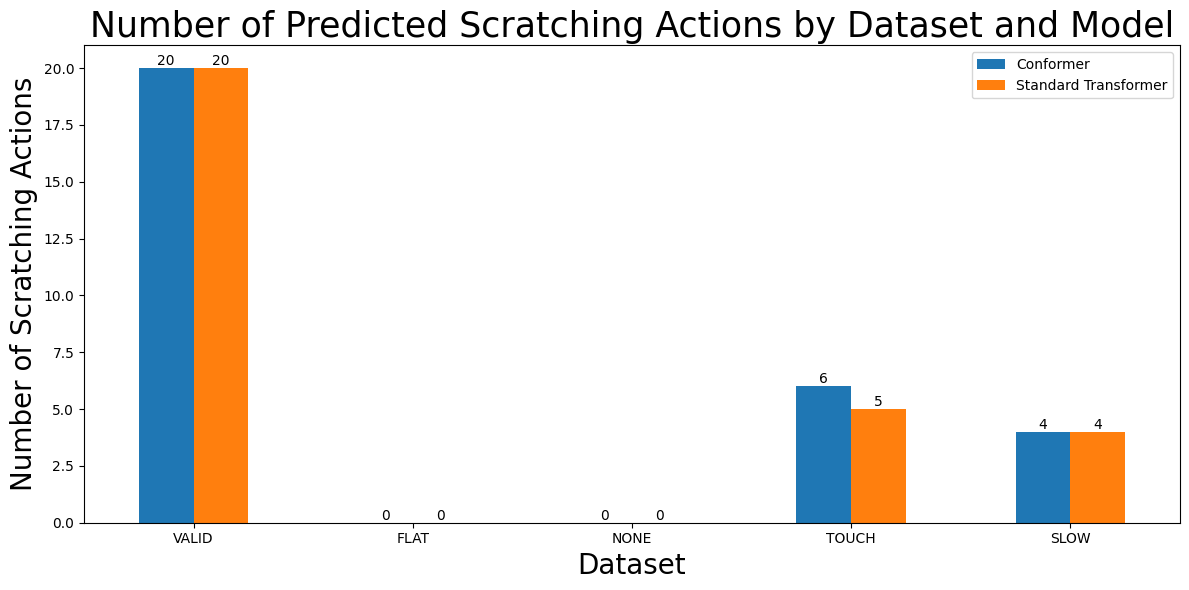

In [16]:
# Create bar charts to visualize the number of scratch events per dataset and model
conformer_scratch_counts = {}
standard_transformer_scratch_counts = {}

for dataset_name, (conformer_preds, standard_transformer_preds) in datasets.items():
    conformer_scratch_counts[dataset_name] = count_scratching_actions(conformer_preds)
    standard_transformer_scratch_counts[dataset_name] = count_scratching_actions(standard_transformer_preds)

# Create a DataFrame from the scratch counts
scratch_counts_df = pd.DataFrame({
    'Conformer': conformer_scratch_counts,
    'Standard Transformer': standard_transformer_scratch_counts
})

# Plot the bar chart
ax = scratch_counts_df.plot(kind='bar', figsize=(12, 6))

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Dataset', fontsize=20)
ax.set_ylabel('Number of Scratching Actions', fontsize=20)
ax.set_title('Number of Predicted Scratching Actions by Dataset and Model', fontsize=25)
plt.xticks(rotation=0)

# Add values on top of the bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

# EFFECT OF WINDOW SIZE/STEP SIZE ON ACCURACY
Analyze and visualize the performance of Conformer and Standard Transformer models for different window sizes and step sizes.

In [17]:
window_sizes = [20, 40, 60, 80]
step_sizes = [10, 20, 30, 40]


Processing Window Size: 20, Step Size: 10
Training Conformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.2344
Epoch 2/5, Val F1: 0.2344
Epoch 3/5, Val F1: 0.3588
Epoch 4/5, Val F1: 0.9639
Epoch 5/5, Val F1: 0.9732
Conformer_ws20_ss10 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       199
           1       0.96      0.98      0.97       136

    accuracy                           0.97       335
   macro avg       0.97      0.97      0.97       335
weighted avg       0.97      0.97      0.97       335



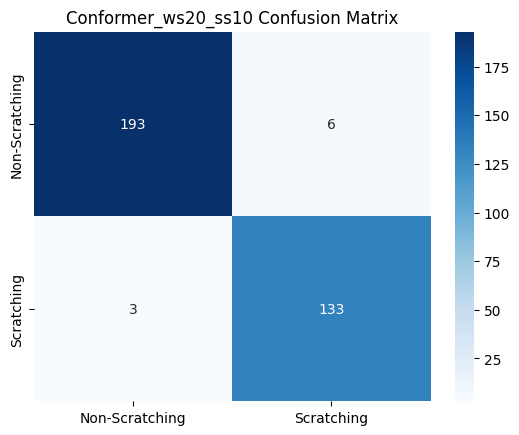


Training Standard Transformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.2409
Epoch 2/5, Val F1: 0.6003
Epoch 3/5, Val F1: 0.9496
Epoch 4/5, Val F1: 0.9761
Epoch 5/5, Val F1: 0.9584
StandardTransformer_ws20_ss10 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       199
           1       0.96      0.98      0.97       136

    accuracy                           0.98       335
   macro avg       0.97      0.98      0.98       335
weighted avg       0.98      0.98      0.98       335



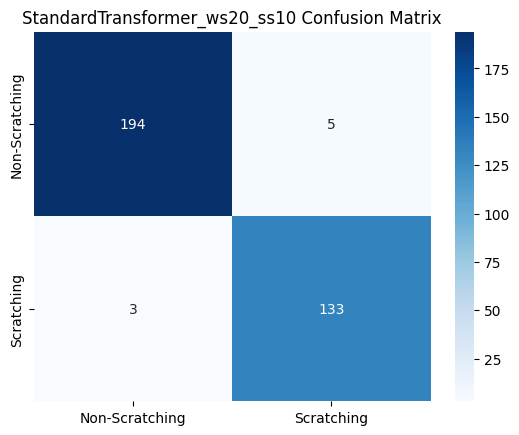


Processing Window Size: 20, Step Size: 20
Training Conformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.2216
Epoch 2/5, Val F1: 0.2216
Epoch 3/5, Val F1: 0.2216
Epoch 4/5, Val F1: 0.4414
Epoch 5/5, Val F1: 0.9821
Conformer_ws20_ss20 Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.95      0.98        66

    accuracy                           0.98       168
   macro avg       0.99      0.98      0.98       168
weighted avg       0.98      0.98      0.98       168



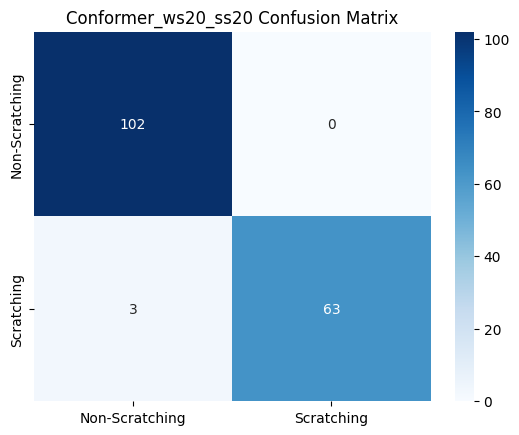


Training Standard Transformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.2216
Epoch 2/5, Val F1: 0.2216
Epoch 3/5, Val F1: 0.6088
Epoch 4/5, Val F1: 0.6812
Epoch 5/5, Val F1: 0.9700
StandardTransformer_ws20_ss20 Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       102
           1       1.00      0.92      0.96        66

    accuracy                           0.97       168
   macro avg       0.98      0.96      0.97       168
weighted avg       0.97      0.97      0.97       168



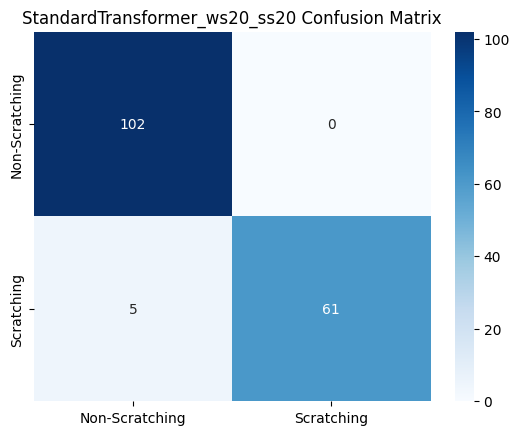


Processing Window Size: 20, Step Size: 30
Training Conformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.2663
Epoch 2/5, Val F1: 0.2663
Epoch 3/5, Val F1: 0.5851
Epoch 4/5, Val F1: 0.6004
Epoch 5/5, Val F1: 0.5928
Conformer_ws20_ss30 Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.38      0.53        63
           1       0.54      0.94      0.69        49

    accuracy                           0.62       112
   macro avg       0.72      0.66      0.61       112
weighted avg       0.74      0.62      0.60       112



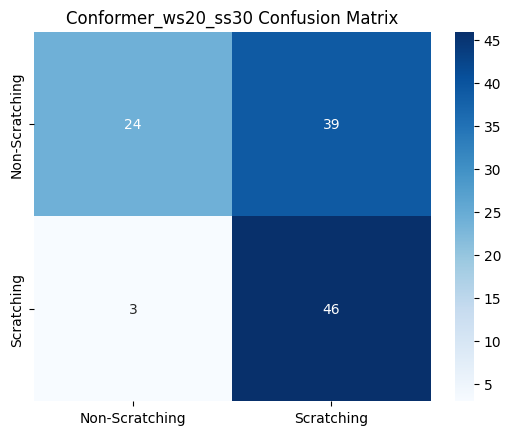


Training Standard Transformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.2663
Epoch 2/5, Val F1: 0.2663
Epoch 3/5, Val F1: 0.2663
Epoch 4/5, Val F1: 0.3403
Epoch 5/5, Val F1: 0.2663
StandardTransformer_ws20_ss30 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.06      0.12        63
           1       0.45      1.00      0.62        49

    accuracy                           0.47       112
   macro avg       0.73      0.53      0.37       112
weighted avg       0.76      0.47      0.34       112



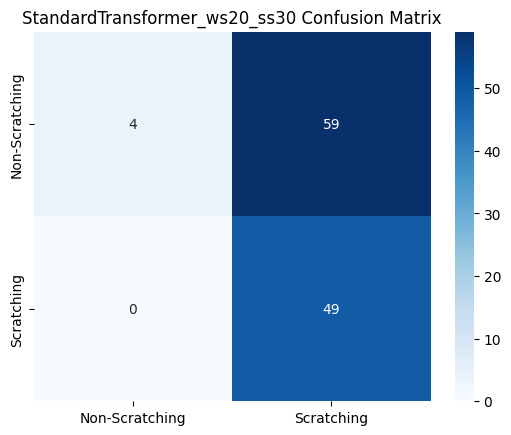


Processing Window Size: 20, Step Size: 40
Training Conformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.1880
Epoch 2/5, Val F1: 0.1880
Epoch 3/5, Val F1: 0.6130
Epoch 4/5, Val F1: 0.1880
Epoch 5/5, Val F1: 0.1880
Conformer_ws20_ss40 Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.44      0.60        54
           1       0.48      0.93      0.64        30

    accuracy                           0.62        84
   macro avg       0.70      0.69      0.62        84
weighted avg       0.77      0.62      0.61        84



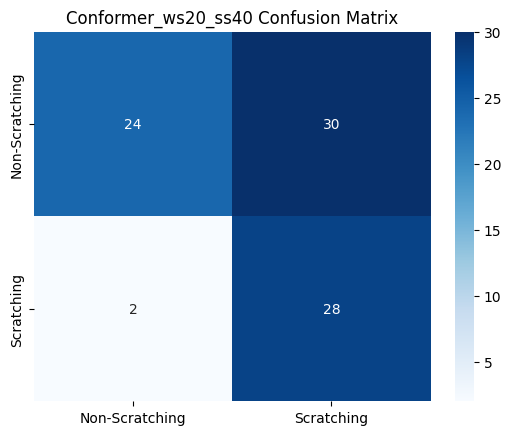


Training Standard Transformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.1880
Epoch 2/5, Val F1: 0.3056
Epoch 3/5, Val F1: 0.3878
Epoch 4/5, Val F1: 0.3478
Epoch 5/5, Val F1: 0.6233
StandardTransformer_ws20_ss40 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.44      0.61        54
           1       0.49      0.97      0.65        30

    accuracy                           0.63        84
   macro avg       0.73      0.71      0.63        84
weighted avg       0.79      0.63      0.62        84



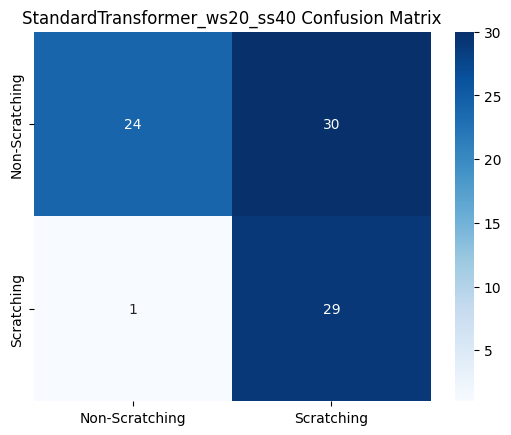


Processing Window Size: 40, Step Size: 10
Training Conformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.3055
Epoch 2/5, Val F1: 0.3055
Epoch 3/5, Val F1: 0.9791
Epoch 4/5, Val F1: 0.9851
Epoch 5/5, Val F1: 0.9791
Conformer_ws40_ss10 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       176
           1       0.99      0.98      0.98       159

    accuracy                           0.99       335
   macro avg       0.99      0.98      0.99       335
weighted avg       0.99      0.99      0.99       335



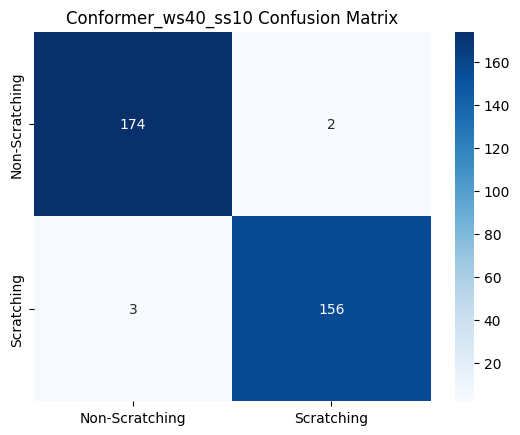


Training Standard Transformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.3055
Epoch 2/5, Val F1: 0.6662
Epoch 3/5, Val F1: 0.9791
Epoch 4/5, Val F1: 0.9791
Epoch 5/5, Val F1: 0.9791
StandardTransformer_ws40_ss10 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       176
           1       0.98      0.97      0.98       159

    accuracy                           0.98       335
   macro avg       0.98      0.98      0.98       335
weighted avg       0.98      0.98      0.98       335



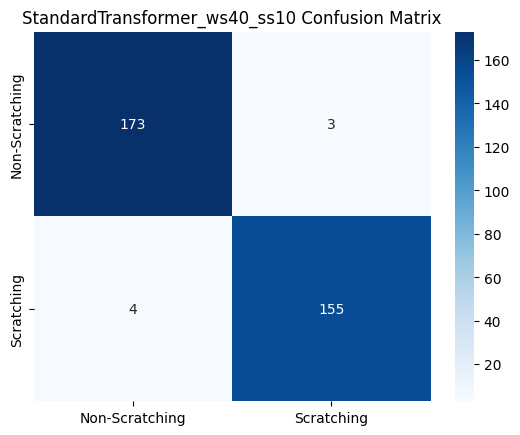


Processing Window Size: 40, Step Size: 20
Training Conformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.2632
Epoch 2/5, Val F1: 0.2632
Epoch 3/5, Val F1: 0.9405
Epoch 4/5, Val F1: 0.9761
Epoch 5/5, Val F1: 0.9524
Conformer_ws40_ss20 Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        95
           1       1.00      0.95      0.97        73

    accuracy                           0.98       168
   macro avg       0.98      0.97      0.98       168
weighted avg       0.98      0.98      0.98       168



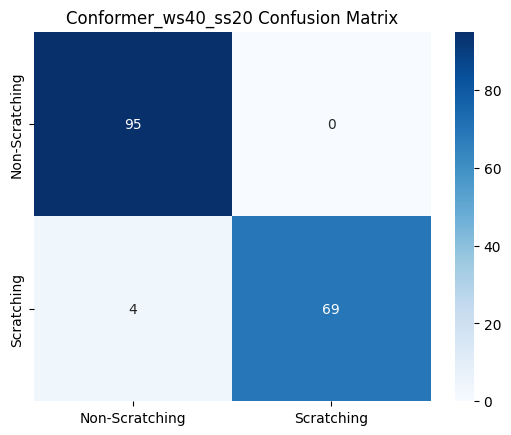


Training Standard Transformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.2632
Epoch 2/5, Val F1: 0.2632
Epoch 3/5, Val F1: 0.6693
Epoch 4/5, Val F1: 0.9702
Epoch 5/5, Val F1: 0.9761
StandardTransformer_ws40_ss20 Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        95
           1       1.00      0.95      0.97        73

    accuracy                           0.98       168
   macro avg       0.98      0.97      0.98       168
weighted avg       0.98      0.98      0.98       168



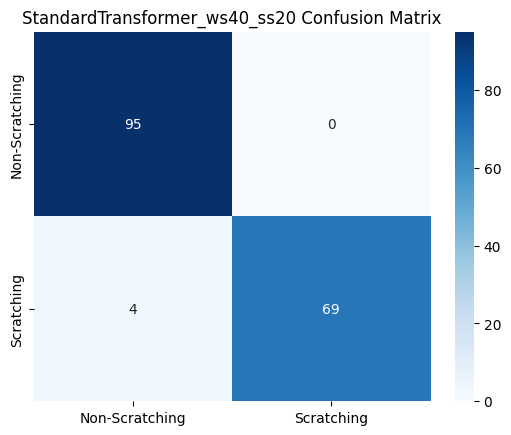


Processing Window Size: 40, Step Size: 30
Training Conformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.1799
Epoch 2/5, Val F1: 0.1799
Epoch 3/5, Val F1: 0.5857
Epoch 4/5, Val F1: 0.5966
Epoch 5/5, Val F1: 0.7723
Conformer_ws40_ss30 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.66      0.79        73
           1       0.60      0.97      0.75        39

    accuracy                           0.77       112
   macro avg       0.79      0.82      0.77       112
weighted avg       0.85      0.77      0.77       112



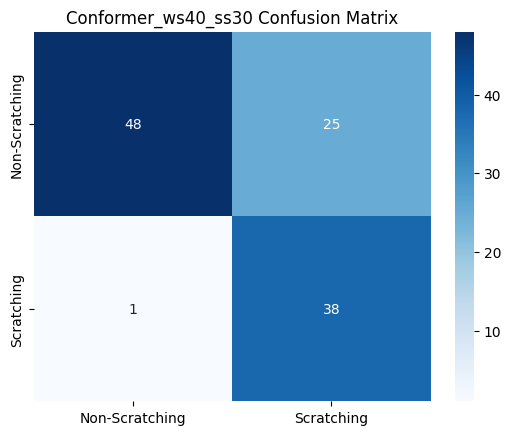


Training Standard Transformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.1799
Epoch 2/5, Val F1: 0.1799
Epoch 3/5, Val F1: 0.1799
Epoch 4/5, Val F1: 0.1799
Epoch 5/5, Val F1: 0.5857
StandardTransformer_ws40_ss30 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.40      0.56        73
           1       0.46      0.97      0.63        39

    accuracy                           0.60       112
   macro avg       0.72      0.69      0.60       112
weighted avg       0.79      0.60      0.59       112



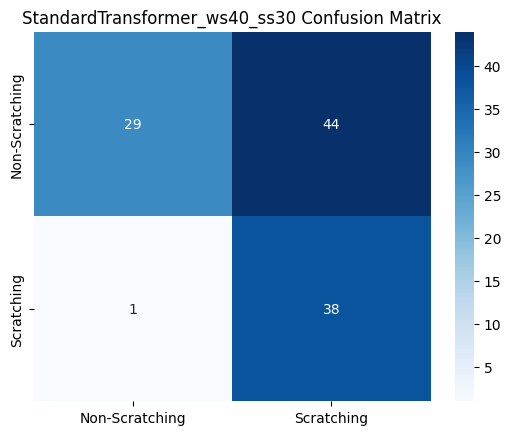


Processing Window Size: 40, Step Size: 40
Training Conformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.2102
Epoch 2/5, Val F1: 0.2102
Epoch 3/5, Val F1: 0.3908
Epoch 4/5, Val F1: 0.6210
Epoch 5/5, Val F1: 0.7883
Conformer_ws40_ss40 Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.69      0.80        52
           1       0.65      0.94      0.77        32

    accuracy                           0.79        84
   macro avg       0.80      0.81      0.78        84
weighted avg       0.83      0.79      0.79        84



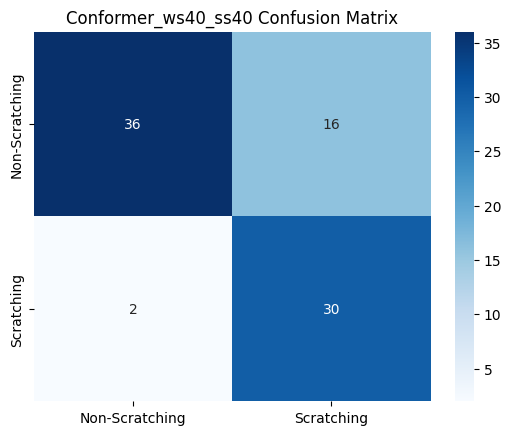


Training Standard Transformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.2102
Epoch 2/5, Val F1: 0.2102
Epoch 3/5, Val F1: 0.2102
Epoch 4/5, Val F1: 0.4484
Epoch 5/5, Val F1: 0.6210
StandardTransformer_ws40_ss40 Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.44      0.60        52
           1       0.51      0.94      0.66        32

    accuracy                           0.63        84
   macro avg       0.71      0.69      0.63        84
weighted avg       0.76      0.63      0.62        84



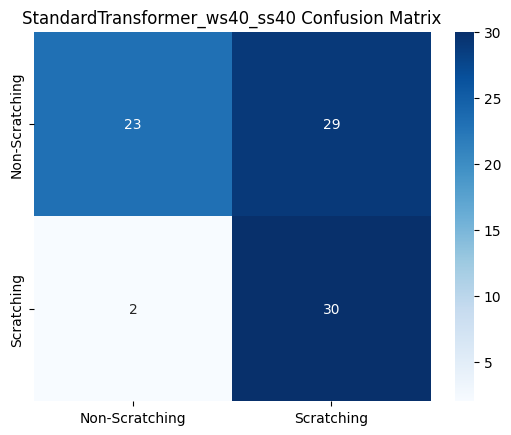


Processing Window Size: 60, Step Size: 10
Training Conformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.2878
Epoch 2/5, Val F1: 0.9313
Epoch 3/5, Val F1: 0.9342
Epoch 4/5, Val F1: 0.9283
Epoch 5/5, Val F1: 0.9313
Conformer_ws60_ss10 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       181
           1       0.89      0.98      0.93       153

    accuracy                           0.93       334
   macro avg       0.93      0.94      0.93       334
weighted avg       0.94      0.93      0.93       334



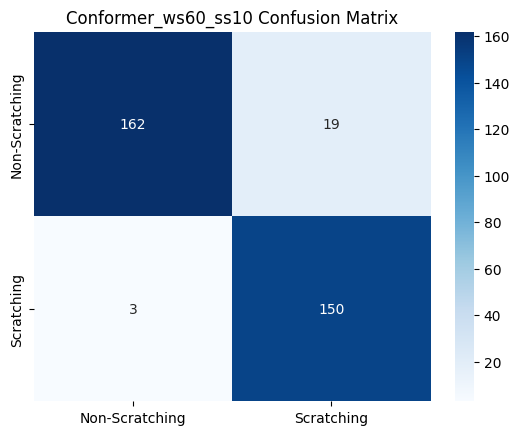


Training Standard Transformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.2878
Epoch 2/5, Val F1: 0.6536
Epoch 3/5, Val F1: 0.9223
Epoch 4/5, Val F1: 0.9253
Epoch 5/5, Val F1: 0.9402
StandardTransformer_ws60_ss10 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94       181
           1       0.90      0.98      0.94       153

    accuracy                           0.94       334
   macro avg       0.94      0.94      0.94       334
weighted avg       0.94      0.94      0.94       334



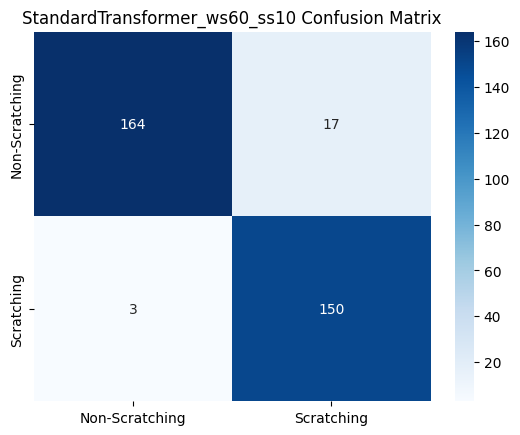


Processing Window Size: 60, Step Size: 20
Training Conformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.6465
Epoch 2/5, Val F1: 0.9522
Epoch 3/5, Val F1: 0.9522
Epoch 4/5, Val F1: 0.9461
Epoch 5/5, Val F1: 0.9581
Conformer_ws60_ss20 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        90
           1       0.94      0.97      0.96        77

    accuracy                           0.96       167
   macro avg       0.96      0.96      0.96       167
weighted avg       0.96      0.96      0.96       167



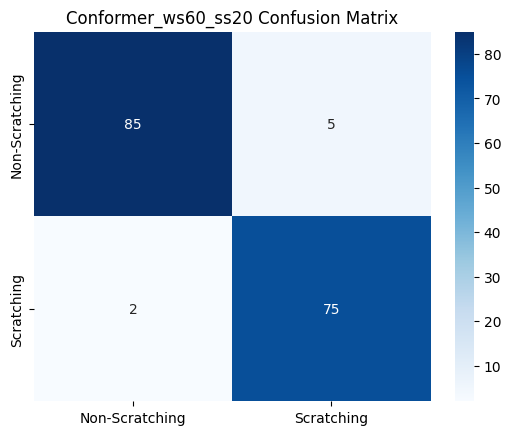


Training Standard Transformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.2910
Epoch 2/5, Val F1: 0.2910
Epoch 3/5, Val F1: 0.2910
Epoch 4/5, Val F1: 0.2910
Epoch 5/5, Val F1: 0.8680
StandardTransformer_ws60_ss20 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.79      0.87        90
           1       0.80      0.96      0.87        77

    accuracy                           0.87       167
   macro avg       0.88      0.87      0.87       167
weighted avg       0.88      0.87      0.87       167



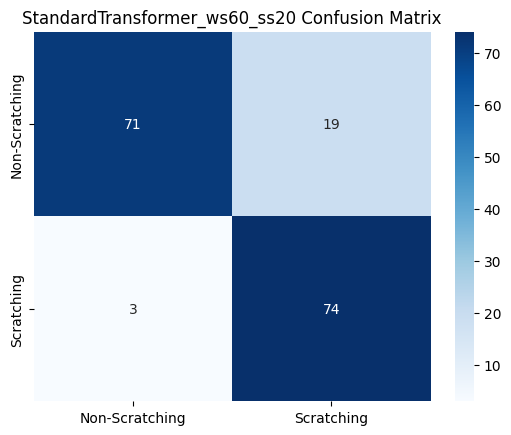


Processing Window Size: 60, Step Size: 30
Training Conformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.1799
Epoch 2/5, Val F1: 0.1799
Epoch 3/5, Val F1: 0.8431
Epoch 4/5, Val F1: 0.9036
Epoch 5/5, Val F1: 0.9383
Conformer_ws60_ss30 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95        73
           1       0.86      0.97      0.92        39

    accuracy                           0.94       112
   macro avg       0.92      0.95      0.93       112
weighted avg       0.94      0.94      0.94       112



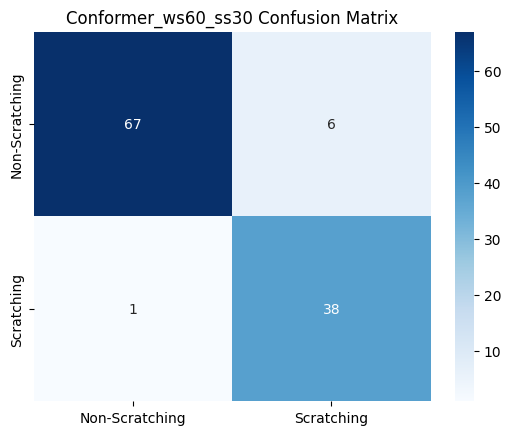


Training Standard Transformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.1799
Epoch 2/5, Val F1: 0.1799
Epoch 3/5, Val F1: 0.1799
Epoch 4/5, Val F1: 0.3939
Epoch 5/5, Val F1: 0.5524
StandardTransformer_ws60_ss30 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.36      0.52        73
           1       0.45      0.97      0.61        39

    accuracy                           0.57       112
   macro avg       0.71      0.67      0.57       112
weighted avg       0.78      0.57      0.55       112



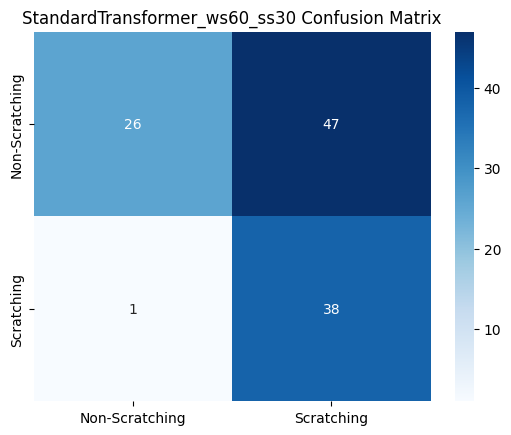


Processing Window Size: 60, Step Size: 40
Training Conformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.1990
Epoch 2/5, Val F1: 0.1990
Epoch 3/5, Val F1: 0.1990
Epoch 4/5, Val F1: 0.6060
Epoch 5/5, Val F1: 0.9293
Conformer_ws60_ss40 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94        53
           1       0.86      0.97      0.91        31

    accuracy                           0.93        84
   macro avg       0.92      0.94      0.93        84
weighted avg       0.93      0.93      0.93        84



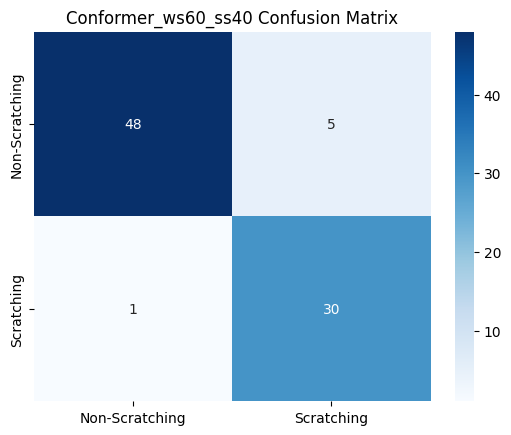


Training Standard Transformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.1990
Epoch 2/5, Val F1: 0.1990
Epoch 3/5, Val F1: 0.1990
Epoch 4/5, Val F1: 0.1990
Epoch 5/5, Val F1: 0.1990
StandardTransformer_ws60_ss40 Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        53
           1       0.37      1.00      0.54        31

    accuracy                           0.37        84
   macro avg       0.18      0.50      0.27        84
weighted avg       0.14      0.37      0.20        84



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


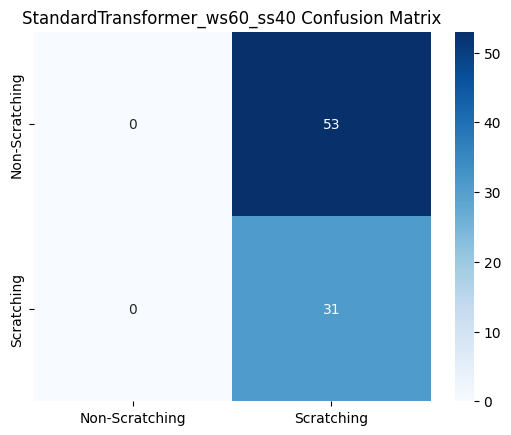


Processing Window Size: 80, Step Size: 10
Training Conformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.3168
Epoch 2/5, Val F1: 0.9370
Epoch 3/5, Val F1: 0.9370
Epoch 4/5, Val F1: 0.9701
Epoch 5/5, Val F1: 0.9761
Conformer_ws80_ss10 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98       172
           1       0.95      1.00      0.98       162

    accuracy                           0.98       334
   macro avg       0.98      0.98      0.98       334
weighted avg       0.98      0.98      0.98       334



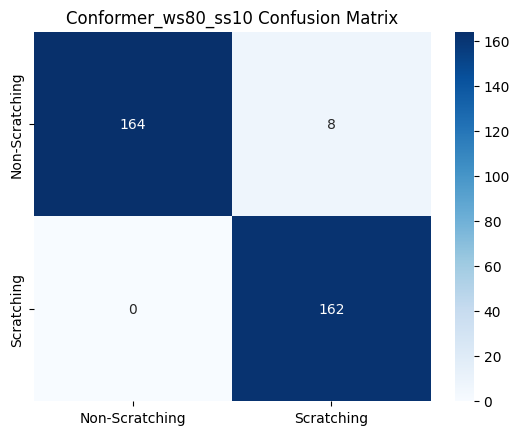


Training Standard Transformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.3168
Epoch 2/5, Val F1: 0.9158
Epoch 3/5, Val F1: 0.9431
Epoch 4/5, Val F1: 0.9641
Epoch 5/5, Val F1: 0.9521
StandardTransformer_ws80_ss10 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96       172
           1       0.94      0.99      0.96       162

    accuracy                           0.96       334
   macro avg       0.96      0.96      0.96       334
weighted avg       0.97      0.96      0.96       334



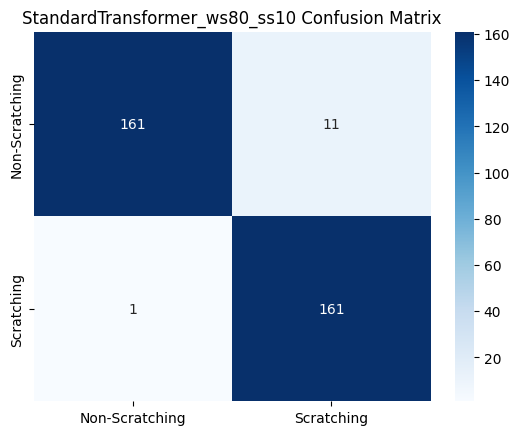


Processing Window Size: 80, Step Size: 20
Training Conformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.3103
Epoch 2/5, Val F1: 0.3234
Epoch 3/5, Val F1: 0.9341
Epoch 4/5, Val F1: 0.9161
Epoch 5/5, Val F1: 0.9521
Conformer_ws80_ss20 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        87
           1       0.93      0.97      0.95        80

    accuracy                           0.95       167
   macro avg       0.95      0.95      0.95       167
weighted avg       0.95      0.95      0.95       167



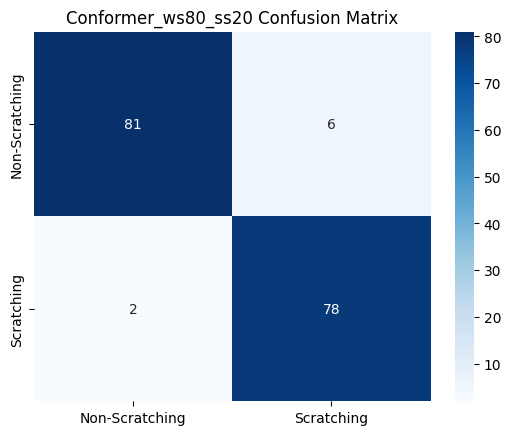


Training Standard Transformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.3103
Epoch 2/5, Val F1: 0.6264
Epoch 3/5, Val F1: 0.9221
Epoch 4/5, Val F1: 0.9341
Epoch 5/5, Val F1: 0.9641
StandardTransformer_ws80_ss20 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97        87
           1       0.95      0.97      0.96        80

    accuracy                           0.96       167
   macro avg       0.96      0.96      0.96       167
weighted avg       0.96      0.96      0.96       167



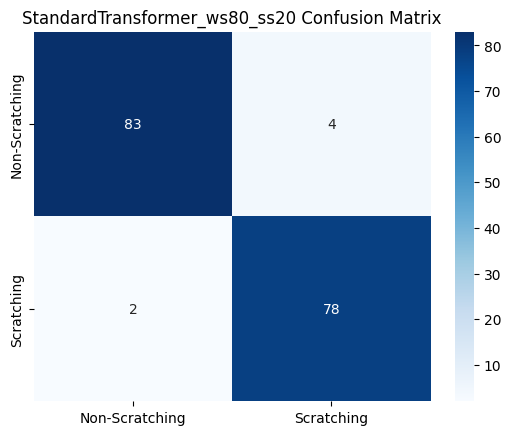


Processing Window Size: 80, Step Size: 30
Training Conformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.1719
Epoch 2/5, Val F1: 0.1719
Epoch 3/5, Val F1: 0.1719
Epoch 4/5, Val F1: 0.8261
Epoch 5/5, Val F1: 0.8696
Conformer_ws80_ss30 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        74
           1       0.72      1.00      0.84        38

    accuracy                           0.87       112
   macro avg       0.86      0.90      0.86       112
weighted avg       0.90      0.87      0.87       112



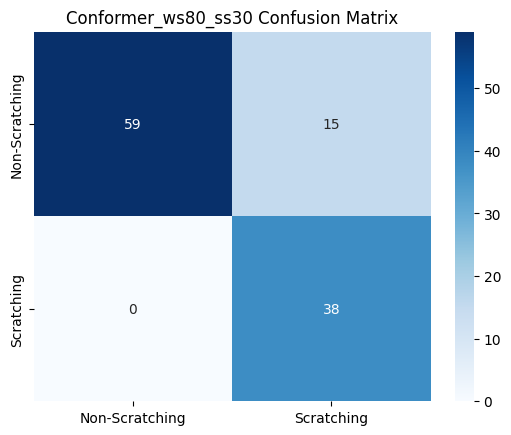


Training Standard Transformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.1719
Epoch 2/5, Val F1: 0.1719
Epoch 3/5, Val F1: 0.1719
Epoch 4/5, Val F1: 0.1719
Epoch 5/5, Val F1: 0.1907
StandardTransformer_ws80_ss30 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.01      0.03        74
           1       0.34      1.00      0.51        38

    accuracy                           0.35       112
   macro avg       0.67      0.51      0.27       112
weighted avg       0.78      0.35      0.19       112



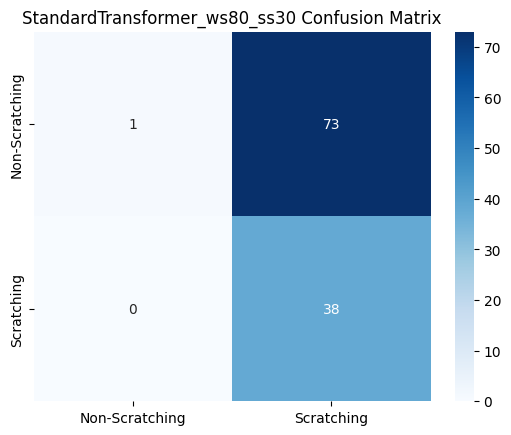


Processing Window Size: 80, Step Size: 40
Training Conformer:


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/5, Val F1: 0.2571
Epoch 2/5, Val F1: 0.2571
Epoch 3/5, Val F1: 0.2571
Epoch 4/5, Val F1: 0.2571
Epoch 5/5, Val F1: 0.2571
Conformer_ws80_ss40 Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        48
           1       0.43      1.00      0.60        36

    accuracy                           0.43        84
   macro avg       0.21      0.50      0.30        84
weighted avg       0.18      0.43      0.26        84



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


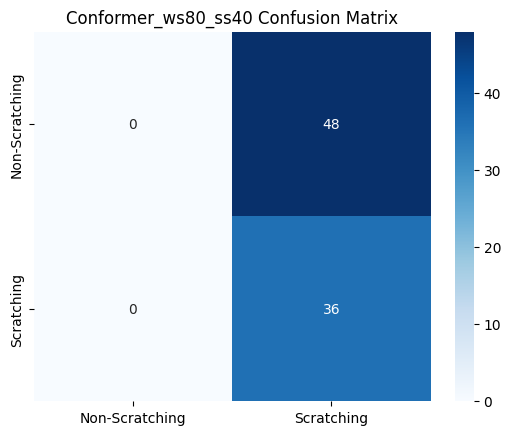

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(



Training Standard Transformer:
Epoch 1/5, Val F1: 0.2571
Epoch 2/5, Val F1: 0.2571
Epoch 3/5, Val F1: 0.3761
Epoch 4/5, Val F1: 0.5885
Epoch 5/5, Val F1: 0.8211
StandardTransformer_ws80_ss40 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.71      0.82        48
           1       0.71      0.97      0.82        36

    accuracy                           0.82        84
   macro avg       0.84      0.84      0.82        84
weighted avg       0.86      0.82      0.82        84



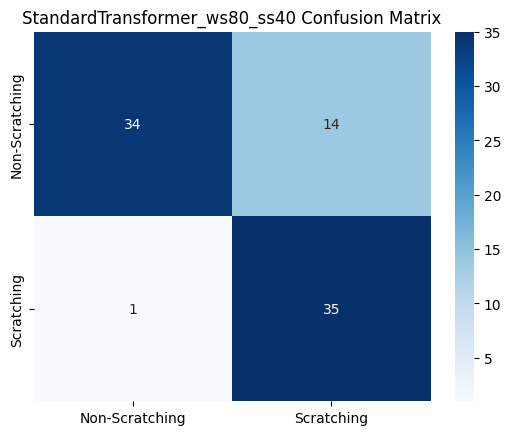

In [18]:
results = []

for window_size in window_sizes:
    for step_size in step_sizes:
        print(f"\nProcessing Window Size: {window_size}, Step Size: {step_size}")

        # Apply windowing to training data
        X_windows_train, y_windows_train = apply_windowing(X_raw, y, window_size, step_size)

        # Apply windowing to validation data
        X_windows_val, y_windows_val = apply_windowing(X_raw_val, y_val, window_size, step_size)

        # Split windowed training data for transformer training
        X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_windows_train, y_windows_train, test_size=0.2, random_state=42)

        # Get input dimension
        input_dim = X_windows_train.shape[2]
        num_classes = 2

        # Train Conformer
        print("Training Conformer:")
        conformer_model = Conformer(input_dim, num_classes)
        conformer_f1 = train_transformer(conformer_model, X_train_t, y_train_t, X_test_t, y_test_t, model_name=f"Conformer_ws{window_size}_ss{step_size}", num_epochs=5) # Reduced epochs for faster iteration

        # Train Standard Transformer
        print("\nTraining Standard Transformer:")
        standard_transformer_model = StandardTransformer(input_dim, num_classes)
        standard_transformer_f1 = train_transformer(standard_transformer_model, X_train_t, y_train_t, X_test_t, y_test_t, model_name=f"StandardTransformer_ws{window_size}_ss{step_size}", num_epochs=5) # Reduced epochs for faster iteration

        # Store results
        results.append({
            'window_size': window_size,
            'step_size': step_size,
            'conformer_f1': conformer_f1,
            'standard_transformer_f1': standard_transformer_f1
        })


In [19]:
results_df = pd.DataFrame(results)

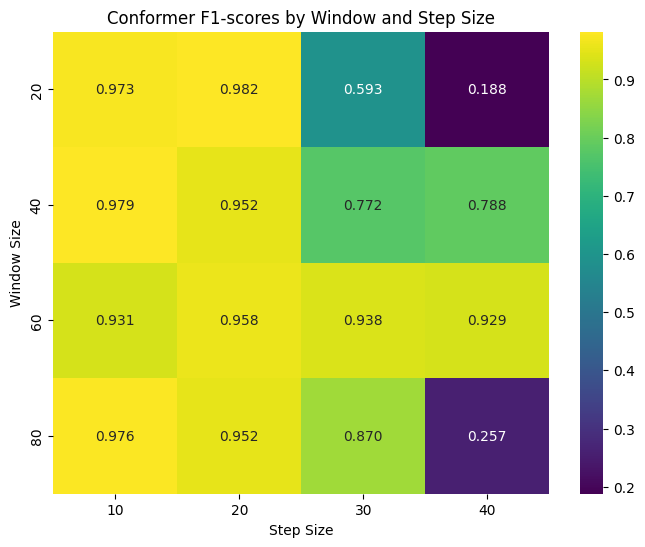

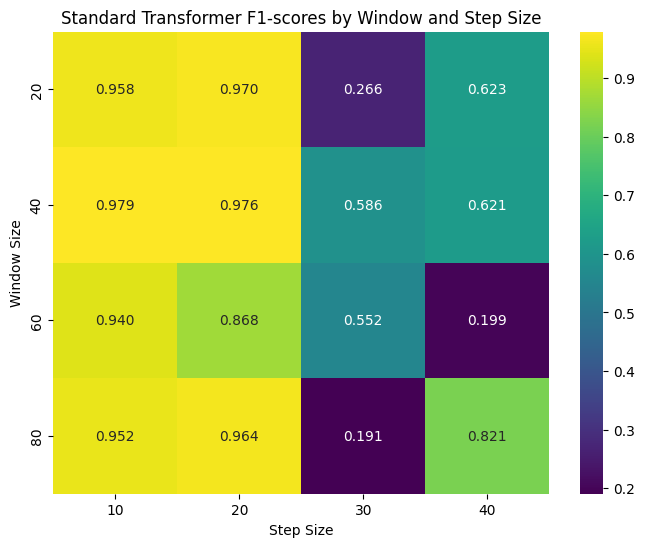

In [20]:
# Create a pivot table for Conformer F1-scores
conformer_pivot = results_df.pivot(index='window_size', columns='step_size', values='conformer_f1')

# Create heatmap for Conformer F1-scores
plt.figure(figsize=(8, 6))
sns.heatmap(conformer_pivot, annot=True, cmap='viridis', fmt=".3f")
plt.title('Conformer F1-scores by Window and Step Size')
plt.xlabel('Step Size')
plt.ylabel('Window Size')
plt.show()

# Create a pivot table for Standard Transformer F1-scores
standard_transformer_pivot = results_df.pivot(index='window_size', columns='step_size', values='standard_transformer_f1')

# Create heatmap for Standard Transformer F1-scores
plt.figure(figsize=(8, 6))
sns.heatmap(standard_transformer_pivot, annot=True, cmap='viridis', fmt=".3f")
plt.title('Standard Transformer F1-scores by Window and Step Size')
plt.xlabel('Step Size')
plt.ylabel('Window Size')
plt.show()